In [1]:
"""
Plan is to deconvolute the macrophage behaviors in the responders pre and post biopsy and show that these matrices can be harmonized
and then do pathway analysis to demonstrate their change in behavior. Pseudobulk them? 
"""



'\nPlan is to deconvolute the macrophage behaviors in the responders pre and post biopsy and show that these matrices can be harmonized\nand then do pathway analysis to demonstrate their change in behavior. Pseudobulk them? \n'

In [2]:
# Core Biopsies
biopsy_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS22-14789/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-4809-A/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/NRS23_22932/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/TMS23-01580/outs']

# Surgical Specimens Only For Now
surg_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS-7945/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-8883/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-13045_rep/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS24-3385-D/outs']

In [ ]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [ ]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


In [4]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


## Core Biopsies

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 4860 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 2256
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
Set parameter GURO_PAR_SPECIAL
Set parameter TokenServer to value "10.201.0.113"


Refining Cell Proportions: 100%|██████████| 2256/2256 [05:44<00:00,  6.55it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
AnnData spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
AnnData spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'

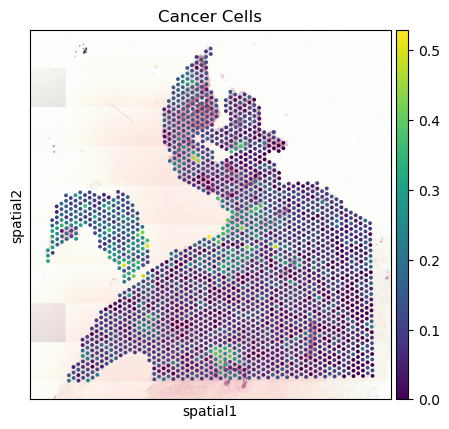

Deconvoluting Remaining Spots: 100%|██████████| 2256/2256 [11:25<00:00,  3.29it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1',
       'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'],
      dtype='object')
Parquet spot names format: ['AACAGGATTCATAGTT-1' 'AACAGGTTATTGCACC-1' 'AACAGGTTCACCGAAG-1'
 'AACAGTCAGGCTCCGC-1' 'AACAGTCCACGCGGTG-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: Macrophages_genes_pass1 (Shape: (2256, 4860))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: B_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: Fibroblasts_genes_pass1 (Shape: (2256, 4860))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (2256, 4860))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTG

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 12251 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 423
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 423/423 [00:57<00:00,  7.37it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1'

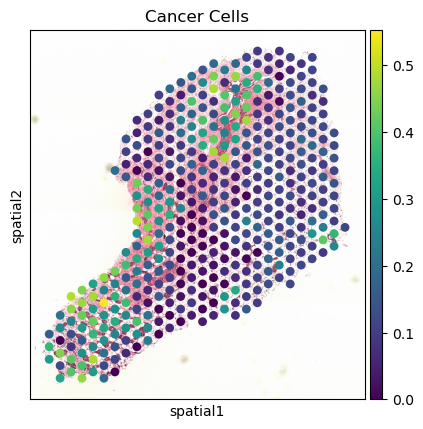

Deconvoluting Remaining Spots: 100%|██████████| 423/423 [01:27<00:00,  4.81it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1',
       'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACTATGCTGCATTCG-1' 'AACTCAACCTTGACCA-1'
 'AACTGCCTCGATAGGT-1' 'AACTTCAGATACTACC-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: Macrophages_genes_pass1 (Shape: (423, 12251))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: B_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: Fibroblasts_genes_pass1 (Shape: (423, 12251))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (423, 12251))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACTATGCTGCA

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2622 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 1783
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 1783/1783 [02:52<00:00, 10.31it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'

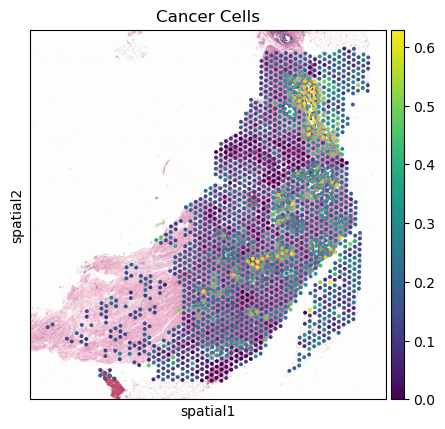

Deconvoluting Remaining Spots: 100%|██████████| 1783/1783 [05:45<00:00,  5.16it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1',
       'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACAGGATTCATAGTT-1' 'AACAGGTTCACCGAAG-1'
 'AACAGTCAGGCTCCGC-1' 'AACAGTCCACGCGGTG-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: Macrophages_genes_pass1 (Shape: (1783, 2622))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: B_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: Fibroblasts_genes_pass1 (Shape: (1783, 2622))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (1783, 2622))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCAT

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 8632 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 320
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 320/320 [00:40<00:00,  7.83it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1'

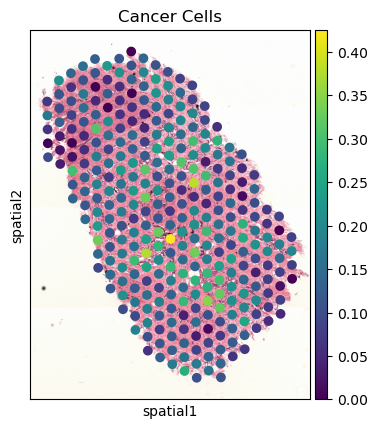

Deconvoluting Remaining Spots: 100%|██████████| 320/320 [01:00<00:00,  5.30it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1',
       'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACCGCCAGACTACTT-1' 'AACTGCCTCGATAGGT-1'
 'AAGGCCGACCTACCTG-1' 'AAGTACTGGATGCGCA-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: Macrophages_genes_pass1 (Shape: (320, 8632))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: B_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: Fibroblasts_genes_pass1 (Shape: (320, 8632))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (320, 8632))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1'

In [5]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


for path in biopsy_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-1]

        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")

    global_cell_type_proportions_df, finetuned_cell_type_proportions_df = model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='global')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    prop_adata = model.get_adata()

    sc.pl.spatial(prop_adata, color = "Cancer Cells")

    
    pass1_results = model.run_cell_expression_pass1(
                radius=400, 
                max_workers=None, 
                checkpoint_interval=100, 
                output_dir="checkpoints", 
                rerun=True
            )

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)






## Surgical Specimens

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 6544 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4992
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4992/4992 [08:49<00:00,  9.42it/s]



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


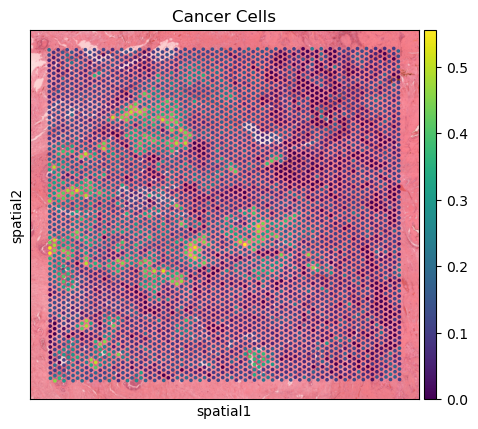

Deconvoluting Remaining Spots: 100%|██████████| 4992/4992 [55:44<00:00,  1.49it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: Macrophages_genes_pass1 (Shape: (4992, 6544))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: B_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: Fibroblasts_genes_pass1 (Shape: (4992, 6544))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4992, 6544))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9527 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4847
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4847/4847 [11:32<00:00,  7.00it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'

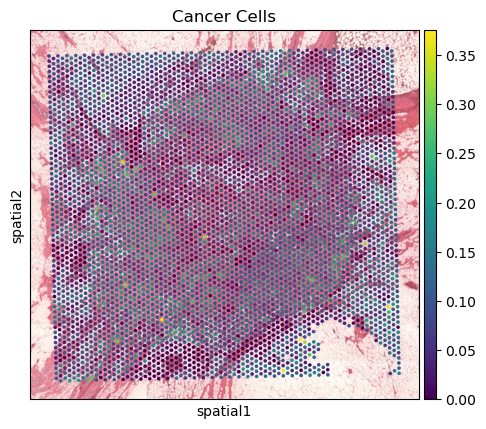

Deconvoluting Remaining Spots: 100%|██████████| 4847/4847 [1:10:11<00:00,  1.15it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: Macrophages_genes_pass1 (Shape: (4847, 9527))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: B_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: Fibroblasts_genes_pass1 (Shape: (4847, 9527))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4847, 9527))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2564 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4450
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4450/4450 [11:13<00:00,  6.61it/s]



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


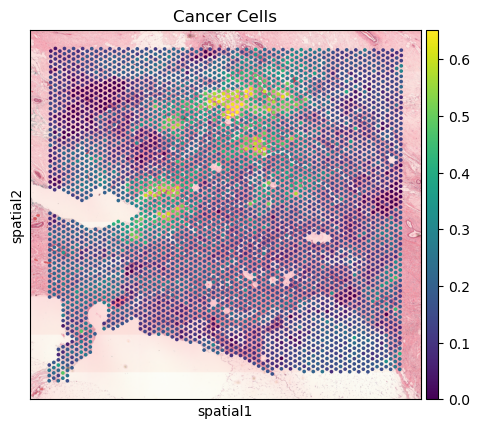

Deconvoluting Remaining Spots: 100%|██████████| 4450/4450 [22:12<00:00,  3.34it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: Macrophages_genes_pass1 (Shape: (4450, 2564))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: B_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: Fibroblasts_genes_pass1 (Shape: (4450, 2564))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4450, 2564))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9509 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4824
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions:  39%|███▉      | 1878/4824 [04:03<06:21,  7.72it/s]


In [ ]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


for path in surg_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-1]

        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")

    global_cell_type_proportions_df, finetuned_cell_type_proportions_df = model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='global')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    prop_adata = model.get_adata()

    sc.pl.spatial(prop_adata, color = "Cancer Cells")

    
    pass1_results = model.run_cell_expression_pass1(
                radius=400, 
                max_workers=None, 
                checkpoint_interval=100, 
                output_dir="checkpoints", 
                rerun=True
            )

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)






# Analyzing Macrophage Behavior (Load from saved files so samples don't have to be re-run)

In [88]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [89]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


In [90]:
# Core Biopsies
biopsy_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS22-14789/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-4809-A/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/NRS23_22932/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/TMS23-01580/outs']

# Surgical Specimens Only For Now
surg_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS-7945/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-8883/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-13045_rep/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS24-3385-D/outs']

In [91]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


In [93]:
biopsy_adatas = {}

for path in biopsy_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-2]


        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")


    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

    biopsy_adatas[sample_name] = prop_gex_adata



/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 4860 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 1898 Filtered spots: 2256 to 1898
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTA

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 12251 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 420 Filtered spots: 423 to 420
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTT

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2622 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 935 Filtered spots: 2142 to 935
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1', 'AACCTAAGAT

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 8632 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 300 Filtered spots: 328 to 300
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCC

In [96]:
surg_adatas = {}

for path in surg_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-2]


        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='global')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

    surg_adatas[sample_name] = prop_gex_adata



/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 6544 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4590 Filtered spots: 4992 to 4590
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9527 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4449 Filtered spots: 4858 to 4449
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2564 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4267 Filtered spots: 4450 to 4267
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9509 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4773 Filtered spots: 4824 to 4773
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAG

In [97]:
all_adatas = []

for sample_name, adata in biopsy_adatas.items():
    # Filter down to the spots where Macrophage Proportion is greater than 0.2
    macrophage_adata = adata[adata.obs['Macrophages'] > 0.2]
    # Then set the X matrix to the Macrophage layers
    macrophage_adata.X = macrophage_adata.layers['Macrophages_genes_pass1']
    macrophage_adata.obs['sample_name'] = sample_name
    macrophage_adata.obs['condition'] = 'Biopsy'
    all_adatas.append(macrophage_adata)
    

for sample_name, adata in surg_adatas.items():
    
    # Filter down to the spots where Macrophage Proportion is greater than 0.2
    macrophage_adata = adata[adata.obs['Macrophages'] > 0.2]
    # Then set the X matrix to the Macrophage layers
    macrophage_adata.X = macrophage_adata.layers['Macrophages_genes_pass1']
    macrophage_adata.obs['sample_name'] = sample_name
    macrophage_adata.obs['condition'] = 'Surgery'
    all_adatas.append(macrophage_adata)
    
    print(sample_name)
    

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_18784/1253406592.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name
/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please mak

MWS-7945


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_18784/1253406592.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name


PVS23-8883
PVS23-13045_rep
PVS24-3385-D


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_18784/1253406592.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name
/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please ma

In [98]:
import anndata as ad
import numpy as np

adata_spots = 0

for adata in all_adatas:
    adata_spots += adata.shape[0]
    
print(adata_spots)

# Create concatenated AnnData object
combined_adata = ad.concat(
    all_adatas,
    join="outer",  # Use outer join to keep all genes
    merge="unique"
)

assert adata_spots == combined_adata.shape[0]
combined_adata.obs_names_make_unique()
print(combined_adata.obs_names)
print(combined_adata.obs['condition'].unique())
print(combined_adata.obs['sample_name'])

combined_adata.X = np.nan_to_num(combined_adata.X, nan=0)


3645


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1',
       'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1', 'AACCTACCTACCGGTT-1',
       'AACCTACTGTAACTCA-1', 'AACGAAGCGTGGAAGT-1', 'AACGAGCTAATAACTA-1',
       'AACGCACTGGTGCTCG-1',
       ...
       'TGGCCAAGCTGGCACC-1', 'TGGCGAATTCTATGGT-1-1', 'TGGCGAGCCACTAGCG-1',
       'TGGTATTAGCTAGACC-1', 'TGGTCGAGATCTGTAA-1', 'TGGTGCATTGTAATCC-1-2',
       'TGTAATGCCTAACACC-1', 'TGTAGGTCTGAACGCA-1-2', 'TGTCAACTCATCAACG-1-1',
       'TGTTGGAACGAGGTCA-1'],
      dtype='object', length=3645)
['Biopsy' 'Surgery']
AACAGGATTCATAGTT-1       MWS22-14789
AACAGGTTATTGCACC-1       MWS22-14789
AACAGGTTCACCGAAG-1       MWS22-14789
AACCAATCTGGTTGGC-1       MWS22-14789
AACCACTAACATGATT-1       MWS22-14789
                            ...     
TGGTGCATTGTAATCC-1-2    PVS24-3385-D
TGTAATGCCTAACACC-1      PVS24-3385-D
TGTAGGTCTGAACGCA-1-2    PVS24-3385-D
TGTCAACTCATCAACG-1-1    PVS24-3385-D
TGTTGGAACGAGGTCA-1      PVS24-3385-D
Name: sample_name, Le

In [99]:
print(combined_adata)

AnnData object with n_obs × n_vars = 3645 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition'
    obsm: 'spatial'
    layers: 'Endothelial_Cells_genes_pass1', 'Macrophages_genes_pass1', 'B_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1'


In [100]:
# Calculate zero percentage - make sure to use the sparse matrix properly
threshold = 0.95
zero_pct = np.sum(combined_adata.X <= threshold, axis=1) / combined_adata.X.shape[1]
print("zero_pct shape:", zero_pct.shape)
# Now filter

print(combined_adata)
combined_adata = combined_adata[zero_pct < 0.95].copy()
print(combined_adata)

zero_pct shape: (3645,)
AnnData object with n_obs × n_vars = 3645 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition'
    obsm: 'spatial'
    layers: 'Endothelial_Cells_genes_pass1', 'Macrophages_genes_pass1', 'B_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1'
AnnData object with n_obs × n_vars = 656 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition'
    obsm: 'spatial'
    layers: 'Endothelial_Cells_genes_pass1', 'Macrophages_genes_pass1', 'B_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'CD8_T_Cells_genes_pas

In [101]:
sc.pp.log1p(combined_adata)
sc.pp.pca(combined_adata)

In [102]:
import scanpy.external as sce
sce.pp.harmony_integrate(combined_adata, 'sample_name')

2025-02-03 16:43:38,588 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-02-03 16:43:39,363 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-02-03 16:43:39,367 - harmonypy - INFO - Iteration 1 of 10
2025-02-03 16:43:39,426 - harmonypy - INFO - Iteration 2 of 10
2025-02-03 16:43:39,484 - harmonypy - INFO - Iteration 3 of 10
2025-02-03 16:43:39,517 - harmonypy - INFO - Iteration 4 of 10
2025-02-03 16:43:39,542 - harmonypy - INFO - Iteration 5 of 10
2025-02-03 16:43:39,570 - harmonypy - INFO - Iteration 6 of 10
2025-02-03 16:43:39,592 - harmonypy - INFO - Iteration 7 of 10
2025-02-03 16:43:39,611 - harmonypy - INFO - Iteration 8 of 10
2025-02-03 16:43:39,630 - harmonypy - INFO - Iteration 9 of 10
2025-02-03 16:43:39,648 - harmonypy - INFO - Iteration 10 of 10
2025-02-03 16:43:39,668 - harmonypy - INFO - Stopped before convergence


In [103]:
sc.set_figure_params(scanpy=True, fontsize=14)

/tmp/ipykernel_18784/2493897932.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(combined_adata, resolution=0.2)
... storing 'sample_name' as categorical
... storing 'condition' as categorical


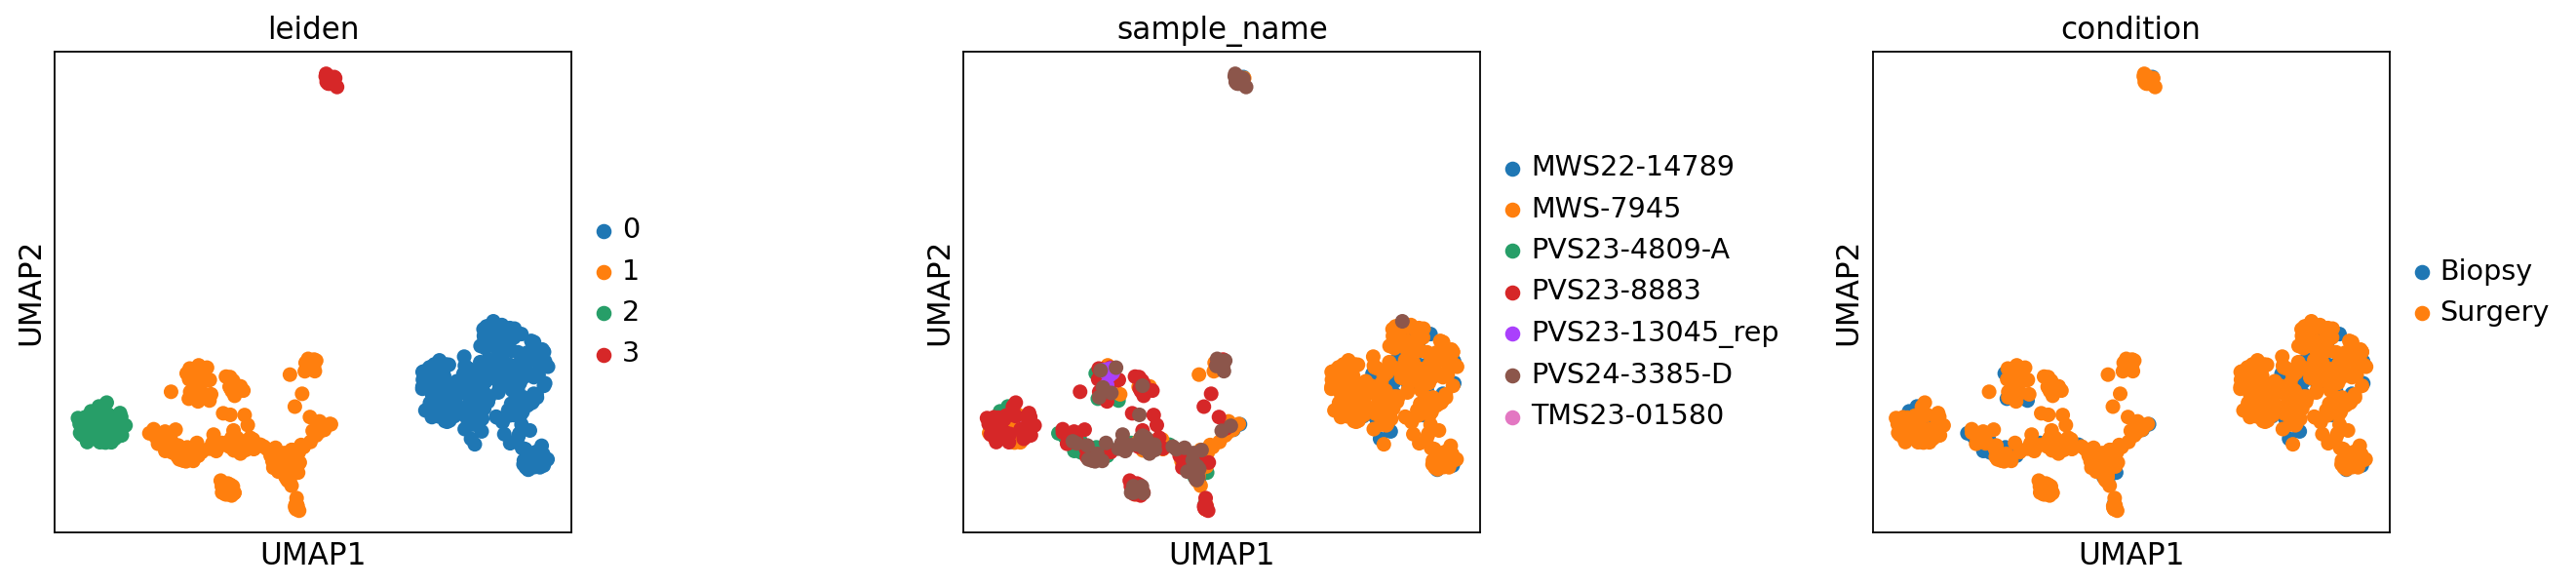

In [104]:
sc.pp.neighbors(combined_adata, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.leiden(combined_adata, resolution=0.2)
sc.tl.umap(combined_adata, min_dist=0.1)   
sc.pl.umap(combined_adata, color=['leiden', 'sample_name', 'condition'], wspace = 0.6)

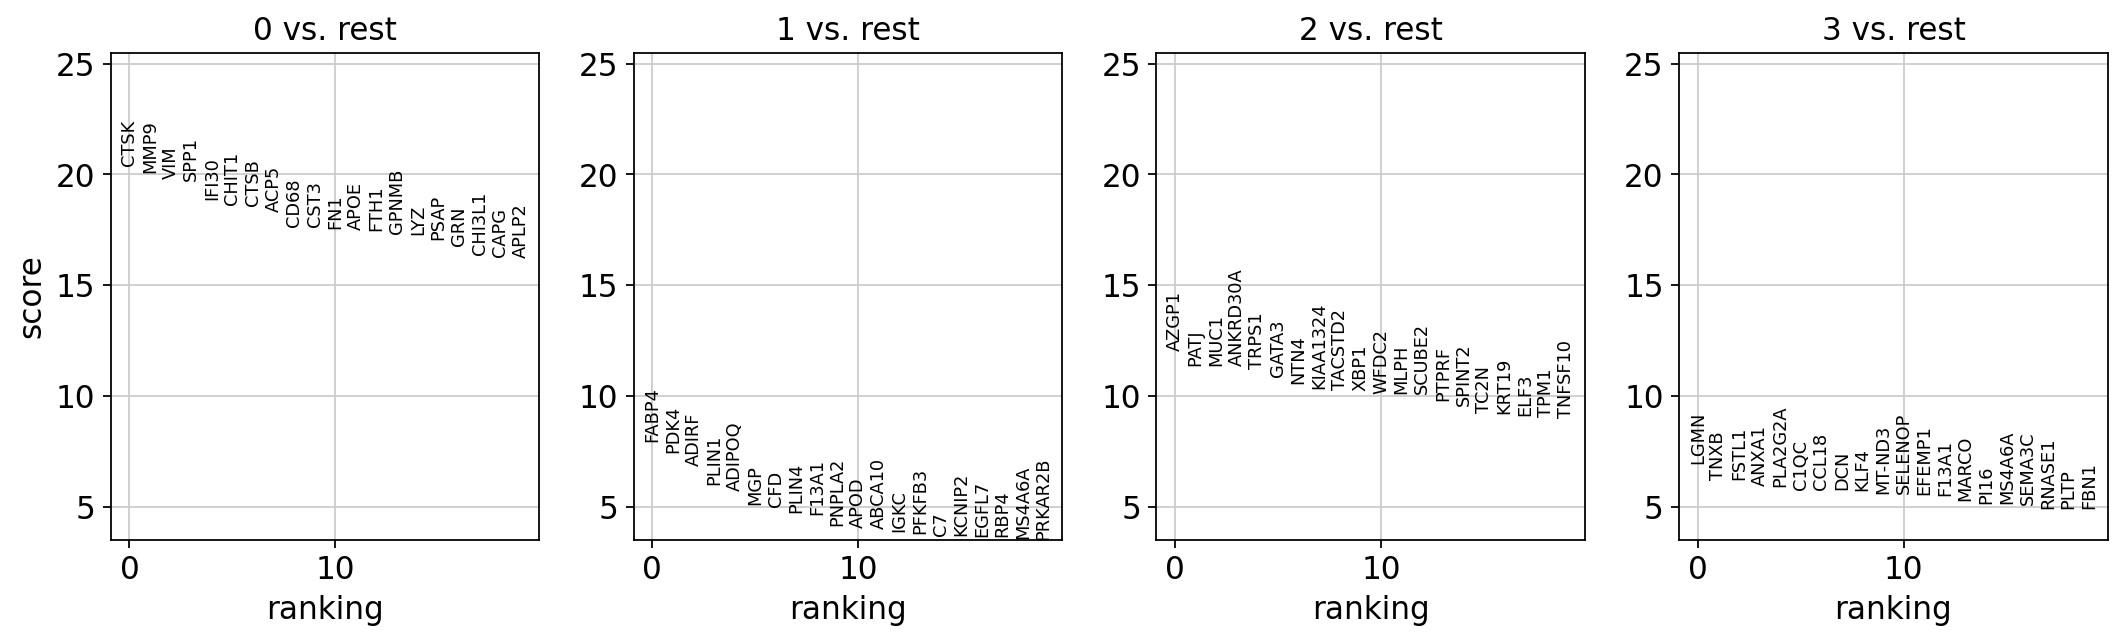

In [105]:
sc.tl.rank_genes_groups(combined_adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(combined_adata)

## PyDeseq2

In [106]:
print(combined_adata)

AnnData object with n_obs × n_vars = 656 × 13266
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'sample_name', 'condition', 'leiden'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'sample_name_colors', 'condition_colors', 'rank_genes_groups'
    obsm: 'spatial', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'Endothelial_Cells_genes_pass1', 'Macrophages_genes_pass1', 'B_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1'
    obsp: 'distances', 'connectivities'


In [107]:
import pydeseq2
import pandas as pd

In [108]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [109]:
counts_array = np.rint(np.expm1(combined_adata.X))
counts_df = pd.DataFrame(
    data=counts_array,
    index=combined_adata.obs_names,
    columns=combined_adata.var_names
)
print(counts_df)

                       A2M  A4GALT  AAAS  AACS  AADAT  AAGAB  AAK1  AAMDC  \
AAGACTCAAGGCTCCA-1     6.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
AAGGCGAGGTTCATGT-1    16.0     0.0   0.0   0.0    0.0    0.0   2.0    0.0   
AATCGGCGCCAACGGT-1    15.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
ACAATACGCCTTATTC-1    42.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
ACGCTCAGTGCACCGT-1    25.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
...                    ...     ...   ...   ...    ...    ...   ...    ...   
TCTTGCACGGTGAGCC-1    19.0     0.0   0.0   0.0    0.0    2.0   2.0    0.0   
TGAGACGTGAACGGTC-1     6.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
TGAGTGCAGAGGACCA-1-2   0.0     0.0   0.0  10.0    0.0    0.0   0.0    0.0   
TGCGTTAGCACGTACC-1-2   0.0     0.0   0.0   0.0    0.0    6.0   0.0    0.0   
TGTTGGAACGAGGTCA-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   

                      AAMP  AAR2  ...  ZUP1  ZW10  ZWILCH  ZWINT  ZXDB  ZXD

In [110]:
sample_name = combined_adata.obs['sample_name']
condition = combined_adata.obs['condition']
print(sample_name.shape)
print(condition.shape)



# Ensure indices are identical before merging
if not sample_name.index.equals(condition.index):
    raise ValueError("Indices do not match between DataFrames!")
else:
    metadata_df = pd.concat([sample_name, condition], axis=1)

    print(metadata_df.shape)

(656,)
(656,)
(656, 2)


In [111]:
print(counts_df.shape)
print(metadata_df.shape)
print(metadata_df)

(656, 13266)
(656, 2)
                       sample_name condition
AAGACTCAAGGCTCCA-1     MWS22-14789    Biopsy
AAGGCGAGGTTCATGT-1     MWS22-14789    Biopsy
AATCGGCGCCAACGGT-1     MWS22-14789    Biopsy
ACAATACGCCTTATTC-1     MWS22-14789    Biopsy
ACGCTCAGTGCACCGT-1     MWS22-14789    Biopsy
...                            ...       ...
TCTTGCACGGTGAGCC-1    PVS24-3385-D   Surgery
TGAGACGTGAACGGTC-1    PVS24-3385-D   Surgery
TGAGTGCAGAGGACCA-1-2  PVS24-3385-D   Surgery
TGCGTTAGCACGTACC-1-2  PVS24-3385-D   Surgery
TGTTGGAACGAGGTCA-1    PVS24-3385-D   Surgery

[656 rows x 2 columns]


genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

In [112]:
metadata_df = metadata_df.loc[counts_df.index]

In [113]:
print(counts_df.shape)
print(metadata_df.shape)

(656, 13266)
(656, 2)


In [114]:
inference = DefaultInference(n_cpus=16)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~condition",
    refit_cooks=True,
    inference=inference,
    size_factors_fit_type="poscounts"
)

In [115]:
dds.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.20 seconds.

Fitting dispersions...
... done in 2.00 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 1.70 seconds.

Fitting LFCs...
... done in 2.01 seconds.

Calculating cook's distance...
... done in 0.77 seconds.

Replacing 19 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.02 seconds.



In [116]:
ds = DeseqStats(
    dds,
    contrast=np.array([0, 1]),
    alpha=0.05,
    cooks_filter=True,
    independent_filter=True,
)

In [117]:
type(ds.summary())

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0 1]
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M     12.586977       -0.562377  0.179987 -3.124535  0.001781  0.061823
A4GALT   0.029065       -0.670016  3.810494 -0.175834  0.860424       NaN
AAAS     0.769771        1.052339  0.551162  1.909309  0.056222  0.368315
AACS     0.540892       -0.494999  0.604184 -0.819285  0.412624       NaN
AADAT    0.174217       -0.122574  1.227035 -0.099895  0.920428       NaN
...           ...             ...       ...       ...       ...       ...
ZXDC     0.258904       -0.382940  1.003503 -0.381603  0.702756       NaN
ZYG11A   0.000000             NaN       NaN       NaN       NaN       NaN
ZYG11B   0.601945        0.989249  0.600400  1.647650  0.099425  0.446964
ZYX      4.794356       -0.143701  0.255616 -0.562176  0.573996  0.817961
ZZEF1    0.884789        0.541024  0.496831  1.088950  0.276176  0.629852

[13266 rows x 6 columns]


... done in 4.43 seconds.



NoneType

In [118]:
df = ds.results_df

In [119]:
print(df)

de_df = df.copy()

df.to_csv('deseq2_results.csv', index=False)

         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M     12.586977       -0.562377  0.179987 -3.124535  0.001781  0.061823
A4GALT   0.029065       -0.670016  3.810494 -0.175834  0.860424       NaN
AAAS     0.769771        1.052339  0.551162  1.909309  0.056222  0.368315
AACS     0.540892       -0.494999  0.604184 -0.819285  0.412624       NaN
AADAT    0.174217       -0.122574  1.227035 -0.099895  0.920428       NaN
...           ...             ...       ...       ...       ...       ...
ZXDC     0.258904       -0.382940  1.003503 -0.381603  0.702756       NaN
ZYG11A   0.000000             NaN       NaN       NaN       NaN       NaN
ZYG11B   0.601945        0.989249  0.600400  1.647650  0.099425  0.446964
ZYX      4.794356       -0.143701  0.255616 -0.562176  0.573996  0.817961
ZZEF1    0.884789        0.541024  0.496831  1.088950  0.276176  0.629852

[13266 rows x 6 columns]


In [120]:
# Volcano plot
print(dds.variables)  # Shows variables in your model

{'condition'}


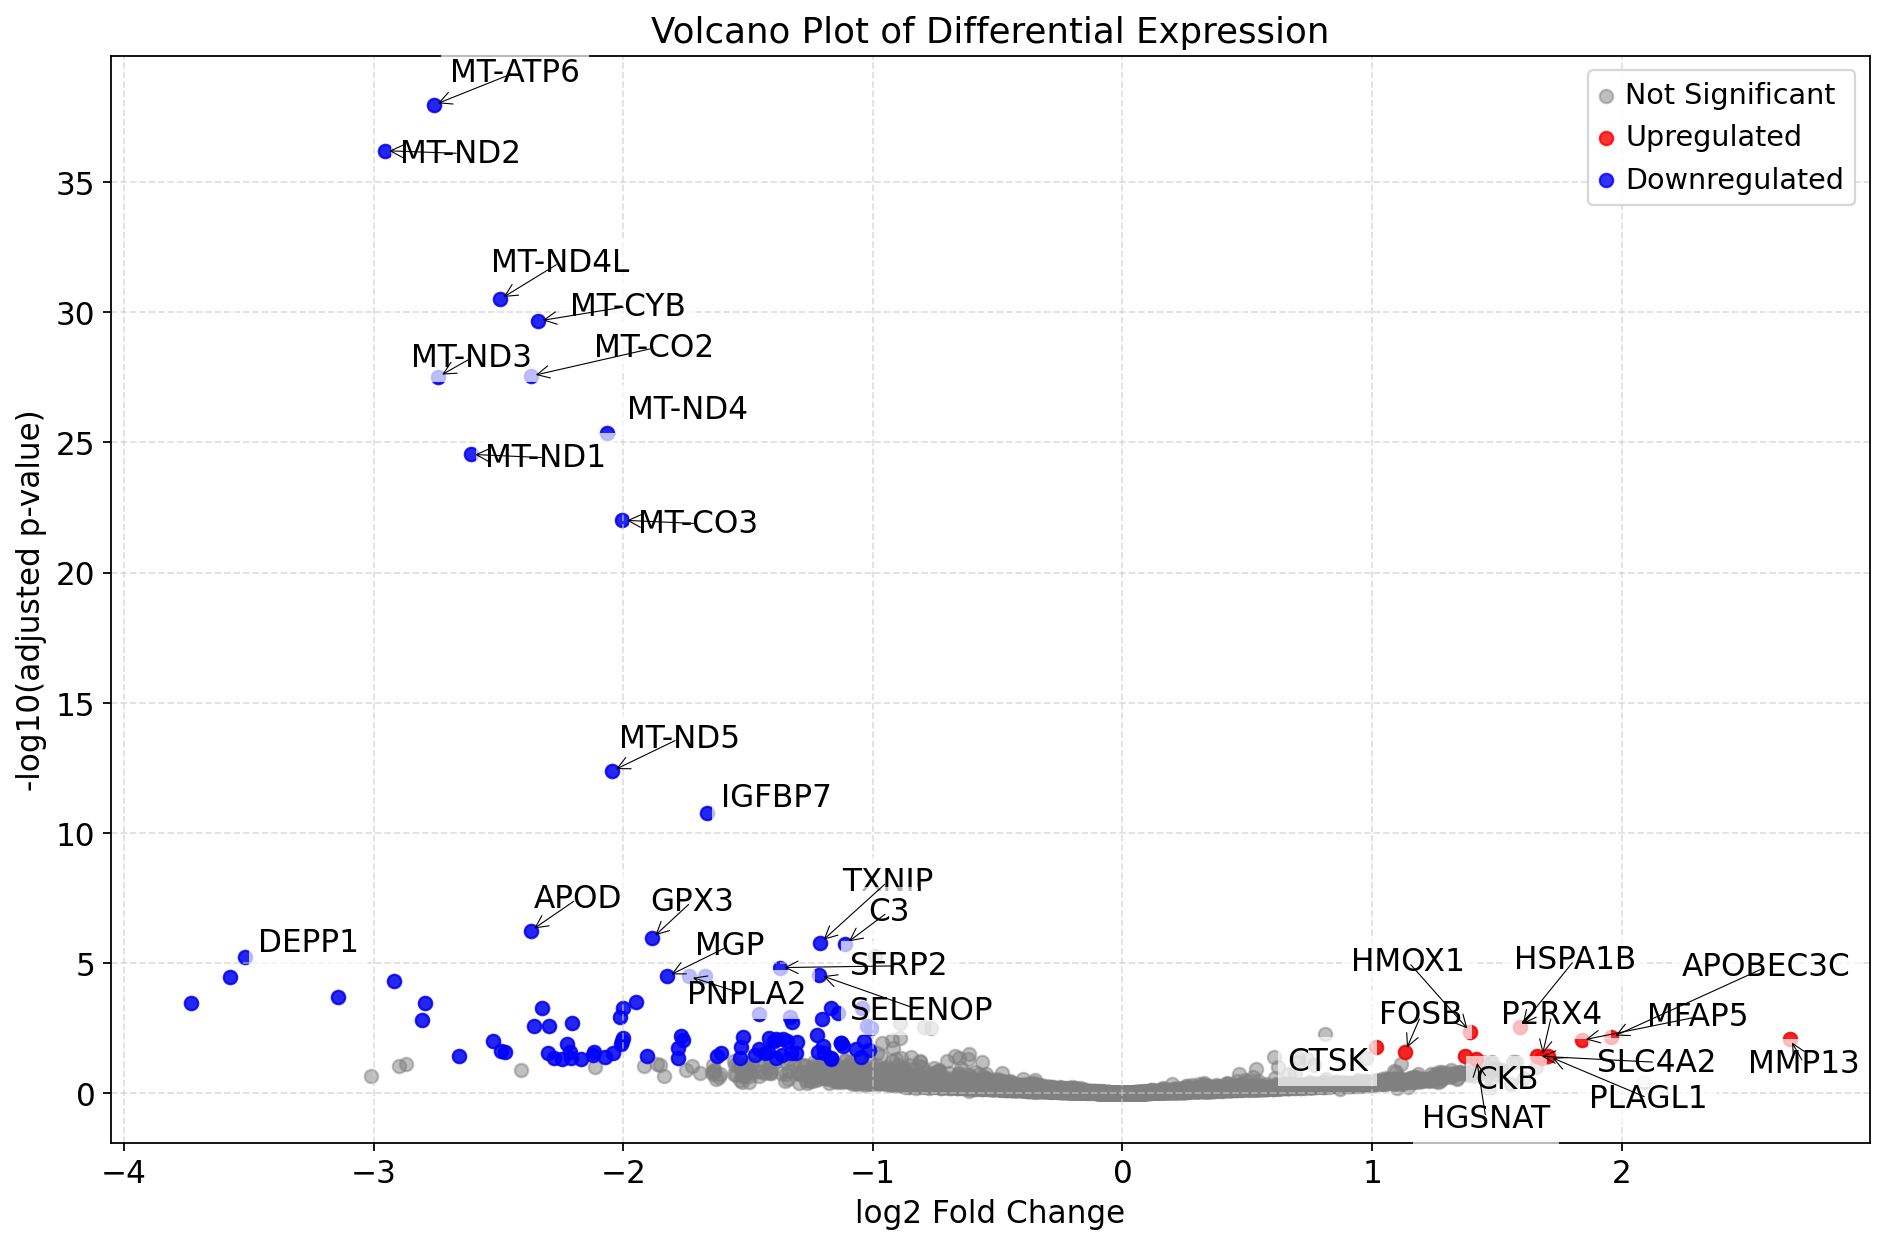


Number of significantly upregulated genes: 12
Number of significantly downregulated genes: 98


In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

# Assuming your dataframe is called 'df'
# Create a boolean mask for significant genes
df['significant'] = (df['padj'] < 0.05) & (abs(df['log2FoldChange']) > 1)

# Create the volcano plot
plt.figure(figsize=(12, 8))

# Plot all points in gray first
plt.scatter(df['log2FoldChange'], 
           -np.log10(df['padj']), 
           color='gray', 
           alpha=0.5, 
           label='Not Significant')

# Highlight significant genes
significant_genes = df[df['significant']]

# Split into up and down regulated
upregulated = significant_genes[significant_genes['log2FoldChange'] > 1]
downregulated = significant_genes[significant_genes['log2FoldChange'] < -1]

# Plot significant points
plt.scatter(upregulated['log2FoldChange'], 
           -np.log10(upregulated['padj']), 
           color='red', 
           alpha=0.8, 
           label='Upregulated')

plt.scatter(downregulated['log2FoldChange'], 
           -np.log10(downregulated['padj']), 
           color='blue', 
           alpha=0.8, 
           label='Downregulated')

# Create list to store all text objects
texts = []

# Label top n up and down regulated genes separately
n_per_direction = 20  # Number of top genes to label in each direction

# For upregulated genes
top_up = upregulated.sort_values('padj').head(n_per_direction)
for idx, row in top_up.iterrows():
    texts.append(plt.text(row['log2FoldChange'], 
                         -np.log10(row['padj']), 
                         idx,
                         fontsize=14,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)))

# For downregulated genes
top_down = downregulated.sort_values('padj').head(n_per_direction)
for idx, row in top_down.iterrows():
    texts.append(plt.text(row['log2FoldChange'], 
                         -np.log10(row['padj']), 
                         idx,
                         fontsize=14,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)))

# Adjust text positions to prevent overlap
adjust_text(texts,
           arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
           expand_points=(1.5, 1.5))

# Add labels and title
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(adjusted p-value)')
plt.title('Volcano Plot of Differential Expression', fontsize=16)

# Add a legend
plt.legend()

# Add grid
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# Print statistics
print(f"\nNumber of significantly upregulated genes: {len(upregulated)}")
print(f"Number of significantly downregulated genes: {len(downregulated)}")
gene_dict = {"Upregulated": upregulated, "Downregulated": downregulated}

### Reading in engulfment gene list

In [122]:
import pandas as pd

df = pd.read_excel('examples/JEM_20221472_TableS4.xlsx', sheet_name='SuppTable4' )

df.columns = df.iloc[1]

df = df.iloc[2:]


df.rename(columns={'GeneSymbol': 'mouse_gene_symbol'}, inplace=True)

print(df)

print(df.columns)

1    mouse_gene_symbol p.value  fdr tdTom-pos.estimated.mean  \
2                Mmp12     0.0  0.0                 1.950867   
3                 Ctss     0.0  0.0                 3.956765   
4                 C1qb     0.0  0.0                 1.507692   
5                Rps28     0.0  0.0                 4.006531   
6                 Ctsc     0.0  0.0                 1.947687   
...                ...     ...  ...                      ...   
9549          Mettl5os     1.0  1.0                 0.012896   
9550             Skap1     1.0  1.0                 0.011459   
9551            March4     1.0  1.0                 0.011505   
9552             Rasef     1.0  1.0                 0.008805   
9553            Ighg2b     1.0  1.0                 0.004657   

1    tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
2                    0.929998        1.020868  0.789537    1.2522    0.581161   
3                    2.993281        0.963484  0.738412  1.188556    

In [123]:
# Filter down to genes that have an FDR < 0.05

df = df[df['fdr'] < 0.05]

print(df)

1    mouse_gene_symbol   p.value       fdr tdTom-pos.estimated.mean  \
2                Mmp12       0.0       0.0                 1.950867   
3                 Ctss       0.0       0.0                 3.956765   
4                 C1qb       0.0       0.0                 1.507692   
5                Rps28       0.0       0.0                 4.006531   
6                 Ctsc       0.0       0.0                 1.947687   
...                ...       ...       ...                      ...   
7361             Kif11  0.049734  0.049734                 0.023967   
7362            Clec4d  0.049818  0.049818                 0.135296   
7363             Phf20  0.049877  0.049877                 0.106217   
7364             Iba57  0.049887  0.049887                 0.022905   
7365             Cdc45  0.049945  0.049945                 0.023058   

1    tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
2                    0.929998        1.020868  0.789537    1.2522 

In [124]:
from pybiomart import Dataset
import pandas as pd
from typing import List

def chunk_list(lst: List[str], chunk_size: int = 200):
    """
    Yield successive chunks of the specified size from the list.
    
    Args:
        lst: List of items.
        chunk_size: Maximum number of items per chunk.
        
    Yields:
        Slices (chunks) of the original list.
    """
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]


# Connect to the Ensembl mouse dataset.
mouse_dataset = Dataset(name='mmusculus_gene_ensembl', host='http://www.ensembl.org')

print(mouse_dataset.filters)
        
gene_ids = df['mouse_gene_symbol'].tolist()[:10]

# Query the dataset for homologs of the rat gene using 'gene_id' filter
result = mouse_dataset.query(attributes=[ 
    'mgi_symbol','ensembl_gene_id'
])

print(result)


df = df.merge(result, left_on='mouse_gene_symbol', right_on='MGI symbol', how='left')

print(df)


{'link_so_mini_closure': <biomart.Filter name='link_so_mini_closure', type='list'>, 'link_go_closure': <biomart.Filter name='link_go_closure', type='text'>, 'link_ensembl_transcript_stable_id': <biomart.Filter name='link_ensembl_transcript_stable_id', type='text'>, 'gene_id': <biomart.Filter name='gene_id', type='text'>, 'transcript_id': <biomart.Filter name='transcript_id', type='text'>, 'link_ensembl_gene_id': <biomart.Filter name='link_ensembl_gene_id', type='text'>, 'chromosome_name': <biomart.Filter name='chromosome_name', type='text'>, 'start': <biomart.Filter name='start', type='text'>, 'end': <biomart.Filter name='end', type='text'>, 'band_start': <biomart.Filter name='band_start', type='drop_down_basic_filter'>, 'band_end': <biomart.Filter name='band_end', type='drop_down_basic_filter'>, 'strand': <biomart.Filter name='strand', type='text'>, 'chromosomal_region': <biomart.Filter name='chromosomal_region', type='text'>, 'id_list_xrefs_filters': <biomart.Filter name='id_list_xre

In [125]:
# Query the dataset for homologs of the rat gene using 'gene_id' filter
result = mouse_dataset.query(attributes=[ 
    'ensembl_gene_id', 'hsapiens_homolog_ensembl_gene'
])

print(result)

           Gene stable ID Human gene stable ID
0      ENSMUSG00000064336                  NaN
1      ENSMUSG00000064337                  NaN
2      ENSMUSG00000064338                  NaN
3      ENSMUSG00000064339                  NaN
4      ENSMUSG00000064340                  NaN
...                   ...                  ...
83574  ENSMUSG00000087203                  NaN
83575  ENSMUSG00000085319                  NaN
83576  ENSMUSG00000086652                  NaN
83577  ENSMUSG00000092353                  NaN
83578  ENSMUSG00000085015                  NaN

[83579 rows x 2 columns]


In [126]:
df = df.merge(result, left_on='Gene stable ID', right_on='Gene stable ID', how='left')

print(df)

     mouse_gene_symbol   p.value       fdr tdTom-pos.estimated.mean  \
0                Mmp12       0.0       0.0                 1.950867   
1                 Ctss       0.0       0.0                 3.956765   
2                 C1qb       0.0       0.0                 1.507692   
3                Rps28       0.0       0.0                 4.006531   
4                 Ctsc       0.0       0.0                 1.947687   
...                ...       ...       ...                      ...   
7533             Kif11  0.049734  0.049734                 0.023967   
7534            Clec4d  0.049818  0.049818                 0.135296   
7535             Phf20  0.049877  0.049877                 0.106217   
7536             Iba57  0.049887  0.049887                 0.022905   
7537             Cdc45  0.049945  0.049945                 0.023058   

     tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
0                    0.929998        1.020868  0.789537    1.2522 

In [127]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')


result = dataset.query(attributes=['ensembl_gene_id','external_gene_name'])

print(result)

        Gene stable ID    Gene name
0      ENSG00000210049        MT-TF
1      ENSG00000211459      MT-RNR1
2      ENSG00000210077        MT-TV
3      ENSG00000210082      MT-RNR2
4      ENSG00000209082       MT-TL1
...                ...          ...
86397  ENSG00000235358     SCMH1-DT
86398  ENSG00000228067    LINC01740
86399  ENSG00000293271  SLC44A3-AS1
86400  ENSG00000310526       WASH7P
86401  ENSG00000241860          NaN

[86402 rows x 2 columns]


In [128]:
df = df.merge(result, left_on='Human gene stable ID', right_on='Gene stable ID', how='left')
print(df)

     mouse_gene_symbol   p.value       fdr tdTom-pos.estimated.mean  \
0                Mmp12       0.0       0.0                 1.950867   
1                 Ctss       0.0       0.0                 3.956765   
2                 C1qb       0.0       0.0                 1.507692   
3                Rps28       0.0       0.0                 4.006531   
4                 Ctsc       0.0       0.0                 1.947687   
...                ...       ...       ...                      ...   
7533             Kif11  0.049734  0.049734                 0.023967   
7534            Clec4d  0.049818  0.049818                 0.135296   
7535             Phf20  0.049877  0.049877                 0.106217   
7536             Iba57  0.049887  0.049887                 0.022905   
7537             Cdc45  0.049945  0.049945                 0.023058   

     tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
0                    0.929998        1.020868  0.789537    1.2522 

In [129]:
df.to_csv('mouse_human_phagocytosis.csv', index=False)

In [130]:
print(df.head())

mouse_df = df.copy()

  mouse_gene_symbol p.value  fdr tdTom-pos.estimated.mean  \
0             Mmp12     0.0  0.0                 1.950867   
1              Ctss     0.0  0.0                 3.956765   
2              C1qb     0.0  0.0                 1.507692   
3             Rps28     0.0  0.0                 4.006531   
4              Ctsc     0.0  0.0                 1.947687   

  tdTom-neg.estimated.mean log2.foldchange    ci.low   ci.high effect.size  \
0                 0.929998        1.020868  0.789537    1.2522    0.581161   
1                 2.993281        0.963484  0.738412  1.188556    0.563748   
2                 0.706236        0.801456  0.592979  1.009934    0.506269   
3                 3.207838        0.798693  0.648395  0.948991    0.699823   
4                 1.159413        0.788274  0.629068   0.94748    0.652048   

  tdTom-pos.specificity tdTom-neg.specificity tdTom-pos.detection.rate  \
0              0.677215              0.322785                  0.48307   
1               

In [132]:
print("de_df.columns", de_df.columns)
print("mouse_df.columns", mouse_df.columns)


de_df.columns Index(['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj'], dtype='object')
mouse_df.columns Index(['mouse_gene_symbol', 'p.value', 'fdr', 'tdTom-pos.estimated.mean',
       'tdTom-neg.estimated.mean', 'log2.foldchange', 'ci.low', 'ci.high',
       'effect.size', 'tdTom-pos.specificity', 'tdTom-neg.specificity',
       'tdTom-pos.detection.rate', 'tdTom-neg.detection.rate', 'MGI symbol',
       'Gene stable ID_x', 'Human gene stable ID', 'Gene stable ID_y',
       'Gene name'],
      dtype='object')


Initial number of human genes: 13266
Number of significant human genes (padj < 0.05): 131
Number of overlapping genes before numeric filtering: 62
Number of overlapping genes after removing NaN: 62

Phagocytosis Gene Analysis Results (Significant Genes Only):
Correlation coefficient: 0.353
Correlation p-value: 4.95e-03
Mean fold change in surgical samples: -1.222
One-sample t-test p-value: 1.38e-12
Proportion of genes upregulated: 11.29%

Top 10 most differentially expressed phagocytosis genes in surgical samples:
Gene name  log2FoldChange  pvalue  padj  log2.foldchange
 SERPINA3          -3.732   0.000 0.000            0.063
   MT-ND2          -2.955   0.000 0.000           -0.691
  MT-ATP6          -2.759   0.000 0.000           -0.643
   MT-ND3          -2.741   0.000 0.000           -0.292
   MT-ND1          -2.612   0.000 0.000           -0.393
  MT-ND4L          -2.494   0.000 0.000            0.421
   MT-CO2          -2.368   0.000 0.000           -0.512
   MT-CYB          -2.34

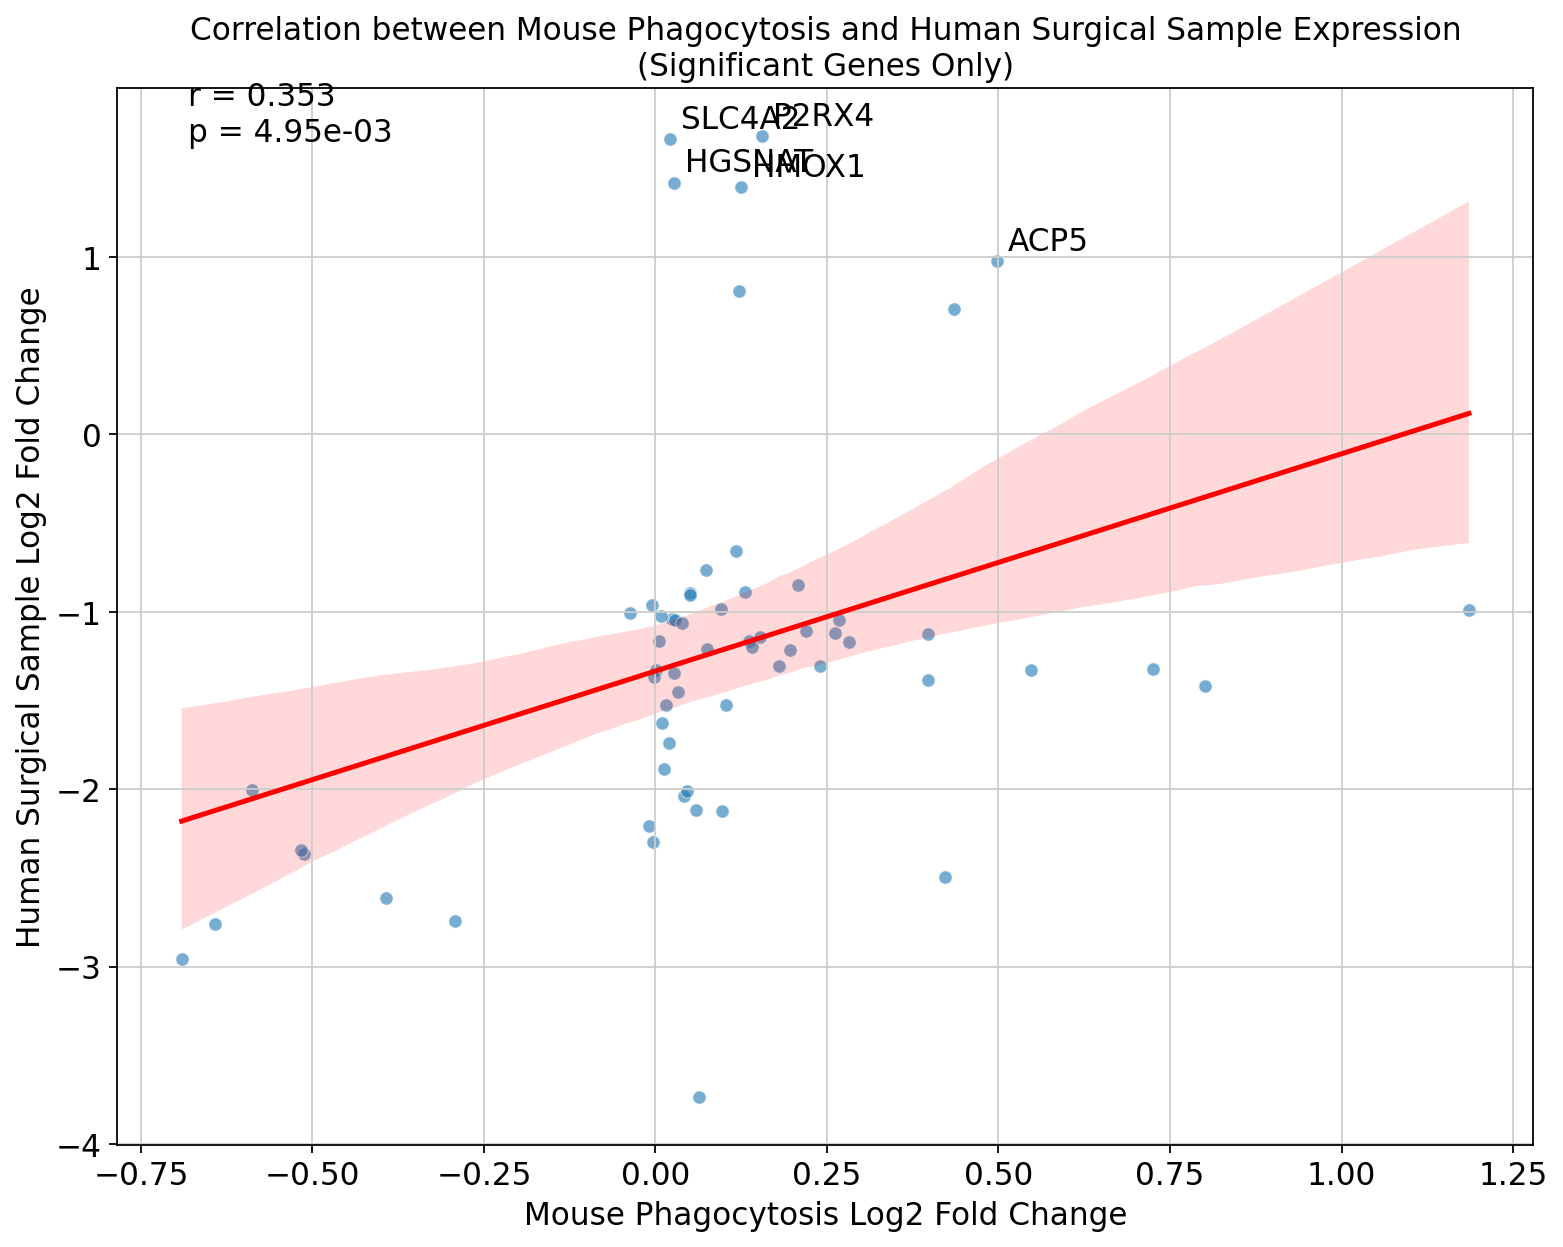

In [135]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_phagocytosis_enrichment(de_df, mouse_df):
    """
    Analyze whether phagocytosis genes are enriched in surgical samples
    
    Parameters:
    de_df: DataFrame with human DESeq results (index should be gene names)
    mouse_df: DataFrame with mouse phagocytosis signature
    
    Returns:
    dict with analysis results and merged DataFrame for plotting
    """
    
    # Print initial number of genes
    print(f"Initial number of human genes: {len(de_df)}")
    
    # Filter human genes for significant adjusted p-values
    de_df = de_df[de_df['padj'].notna() & (de_df['padj'] < 0.05)].copy()
    print(f"Number of significant human genes (padj < 0.05): {len(de_df)}")
    
    # Create merged dataset of overlapping genes
    merged_df = pd.merge(
        de_df.reset_index().rename(columns={'index': 'gene_name'}),
        mouse_df,
        left_on='gene_name',
        right_on='Gene name',
        how='inner'
    )
    
    # Print number of genes before filtering
    print(f"Number of overlapping genes before numeric filtering: {len(merged_df)}")
    
    # Convert columns to numeric, replacing non-numeric values with NaN
    merged_df['log2FoldChange'] = pd.to_numeric(merged_df['log2FoldChange'], errors='coerce')
    merged_df['log2.foldchange'] = pd.to_numeric(merged_df['log2.foldchange'], errors='coerce')
    merged_df['pvalue'] = pd.to_numeric(merged_df['pvalue'], errors='coerce')
    
    # Filter out rows with NaN values in key columns
    merged_df = merged_df.dropna(subset=['log2FoldChange', 'log2.foldchange'])
    
    print(f"Number of overlapping genes after removing NaN: {len(merged_df)}")
    
    if len(merged_df) == 0:
        print("No overlapping genes found after filtering!")
        return None
        
    # Calculate correlation between mouse phagocytosis and human surgical fold changes
    correlation, p_value = stats.pearsonr(
        merged_df['log2.foldchange'].astype(float),  # Mouse phagocytosis fold change
        merged_df['log2FoldChange'].astype(float)    # Human surgical fold change
    )
    
    # Calculate mean fold change in surgical samples for phagocytosis genes
    mean_surgical_fc = merged_df['log2FoldChange'].mean()
    
    # Perform one-sample t-test to see if fold changes are significantly different from 0
    t_stat, t_pval = stats.ttest_1samp(merged_df['log2FoldChange'], 0)
    
    # Calculate what proportion of phagocytosis genes are upregulated in surgical samples
    n_up = (merged_df['log2FoldChange'] > 0).sum()
    n_total = len(merged_df)
    prop_up = n_up / n_total if n_total > 0 else 0
    
    # Create visualization
    plt.figure(figsize=(10, 8))
    
    # Scatter plot
    sns.scatterplot(
        data=merged_df,
        x='log2.foldchange',     # Mouse phagocytosis fold change
        y='log2FoldChange',      # Human surgical fold change
        alpha=0.6
    )
    
    # Add trend line
    sns.regplot(
        data=merged_df,
        x='log2.foldchange',
        y='log2FoldChange',
        scatter=False,
        color='red'
    )
    
    # Add gene labels for top differentially expressed genes
    for _, row in merged_df.nlargest(5, 'log2FoldChange').iterrows():
        plt.annotate(
            row['Gene name'],
            (row['log2.foldchange'], row['log2FoldChange']),
            xytext=(5, 5),
            textcoords='offset points'
        )
    
    plt.title('Correlation between Mouse Phagocytosis and Human Surgical Sample Expression\n(Significant Genes Only)')
    plt.xlabel('Mouse Phagocytosis Log2 Fold Change')
    plt.ylabel('Human Surgical Sample Log2 Fold Change')
    
    # Add correlation annotation
    plt.annotate(
        f'r = {correlation:.3f}\np = {p_value:.2e}',
        xy=(0.05, 0.95),
        xycoords='axes fraction'
    )
    
    # Compile results
    results = {
        'correlation': correlation,
        'correlation_pvalue': p_value,
        'mean_surgical_fc': mean_surgical_fc,
        't_statistic': t_stat,
        't_pvalue': t_pval,
        'n_phagocytosis_genes': n_total,
        'n_upregulated': n_up,
        'proportion_upregulated': prop_up,
        'merged_data': merged_df
    }
    
    # Print summary statistics
    print("\nPhagocytosis Gene Analysis Results (Significant Genes Only):")
    print(f"Correlation coefficient: {correlation:.3f}")
    print(f"Correlation p-value: {p_value:.2e}")
    print(f"Mean fold change in surgical samples: {mean_surgical_fc:.3f}")
    print(f"One-sample t-test p-value: {t_pval:.2e}")
    print(f"Proportion of genes upregulated: {prop_up:.2%}")
    
    # Get top genes by absolute fold change
    top_genes = merged_df.copy()
    top_genes['abs_fc'] = abs(top_genes['log2FoldChange'])
    top_genes = top_genes.nlargest(10, 'abs_fc')[
        ['Gene name', 'log2FoldChange', 'pvalue', 'padj', 'log2.foldchange']
    ].round(3)
    
    print("\nTop 10 most differentially expressed phagocytosis genes in surgical samples:")
    pd.set_option('display.max_columns', None)
    print(top_genes.to_string(index=False))
    
    plt.tight_layout()
    return results

# Now you can run the analysis with:
results = analyze_phagocytosis_enrichment(de_df, mouse_df)